# This notebook is for overall model predicitons over the 3 tournaments

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
import re
import warnings

warnings.filterwarnings('ignore')

In [24]:
# -- read in ACC files
acc_all_champions_predictions_detailed_df = pd.read_csv('ACC_All_Champions_Predictions_Detailed.csv')
acc_all_matches_accuracy_df = pd.read_csv('ACC_All_Matches_Accuracy.csv')
acc_all_regular_matches_accuracy_df = pd.read_csv('ACC_All_Regular_Matches_Accuracy.csv')
acc_champion_accuracy_df = pd.read_csv('ACC_Champion_Accuracy.csv')

# -- read in Big Ten files
big_ten_all_champions_predictions_detailed_df = pd.read_csv('Big_Ten_All_Champions_Predictions_Detailed.csv')
big_ten_all_matches_accuracy_df = pd.read_csv('Big_Ten_All_Matches_Accuracy.csv')
big_ten_all_regular_matches_accuracy_df = pd.read_csv('Big_Ten_All_Regular_Matches_Accuracy.csv')
big_ten_champion_accuracy_df = pd.read_csv('Big_Ten_Champion_Accuracy.csv')

# -- read in Ivy files
ivy_all_champions_predictions_detailed_df = pd.read_csv('IVY_All_Champions_Predictions_Detailed.csv')
ivy_all_matches_accuracy_df = pd.read_csv('IVY_All_Matches_Accuracy.csv')
ivy_all_regular_matches_accuracy_df = pd.read_csv('IVY_ALL_Regular_Matches_Accuracy.csv') # Corrected filename
ivy_champion_accuracy_df = pd.read_csv('IVY_Champion_Accuracy.csv')

print("All CSVs loaded successfully!")

All CSVs loaded successfully!


In [25]:
# Display the first few rows of each DataFrame to verify
print("\nACC_All_Champions_Predictions_Detailed.csv head:")
display(acc_all_champions_predictions_detailed_df.head())

print("\nACC_All_Matches_Accuracy.csv head:")
display(acc_all_matches_accuracy_df.head())

print("\nACC_All_Regular_Matches_Accuracy.csv head:")
display(acc_all_regular_matches_accuracy_df.head())

print("\nACC_Champion_Accuracy.csv head:")
display(acc_champion_accuracy_df.head())

print("\nBig_Ten_All_Champions_Predictions_Detailed.csv head:")
display(big_ten_all_champions_predictions_detailed_df.head())

print("\nBig_Ten_All_Matches_Accuracy.csv head:")
display(big_ten_all_matches_accuracy_df.head())

print("\nBig_Ten_All_Regular_Matches_Accuracy.csv head:")
display(big_ten_all_regular_matches_accuracy_df.head())

print("\nBig_Ten_Champion_Accuracy.csv head:")
display(big_ten_champion_accuracy_df.head())

print("\nIVY_All_Champions_Predictions_Detailed.csv head:")
display(ivy_all_champions_predictions_detailed_df.head())

print("\nIVY_All_Matches_Accuracy.csv head:")
display(ivy_all_matches_accuracy_df.head())

print("\nIVY_All_Regular_Matches_Accuracy.csv head:")
display(ivy_all_regular_matches_accuracy_df.head())

print("\nIVY_Champion_Accuracy.csv head:")
display(ivy_champion_accuracy_df.head())


ACC_All_Champions_Predictions_Detailed.csv head:


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Eddie Ventresca (Virginia Tech),Eddie Ventresca,Eddie Ventresca,Eddie Ventresca,Eddie Ventresca,Unanimous,✅
1,133 lbs,Aaron Seidel (Virginia Tech),Tyler Knox,Aaron Seidel,Aaron Seidel,Aaron Seidel,3/4 Models,❌
2,141 lbs,Jack Consiglio (Stanford),Gable Porter,Gable Porter,Ryan Jack,Ryan Jack,Split Decision,❌
3,149 lbs,Collin Gaj (Virginia Tech),Koy Buesgens,Koy Buesgens,Koy Buesgens,Koy Buesgens,Unanimous,❌
4,157 lbs,Daniel Cardenas (Stanford),Daniel Cardenas,Daniel Cardenas,Daniel Cardenas,Daniel Cardenas,Unanimous,✅



ACC_All_Matches_Accuracy.csv head:


,Model,Correct,Total,Accuracy
0,XGBoost (with ranks),81,107,75.7
1,XGBoost (no ranks),78,107,72.9
2,Logistic Regression,76,107,71.0
3,Decision Tree,74,107,69.2



ACC_All_Regular_Matches_Accuracy.csv head:


...

,Model,Correct,Accuracy
0,Logistic Regression,69/87,79.3%
1,XGBoost (no ranks),69/87,79.3%
2,Decision Tree,68/87,78.2%
3,XGBoost (with ranks),65/87,74.7%



IVY_All_Regular_Matches_Accuracy.csv head:


,Model,Correct,Accuracy
0,Logistic Regression,69/86,80.2%
1,XGBoost (no ranks),69/86,80.2%
2,Decision Tree,68/86,79.1%
3,XGBoost (with ranks),64/86,74.4%



IVY_Champion_Accuracy.csv head:


,Model,Correct Champions,Accuracy
0,LOGREG,7/10,70.0%
1,DT,6/10,60.0%
2,XGB1,7/10,70.0%
3,XGB2,6/10,60.0%



📊 OVERALL CROSS-CONFERENCE MODEL PERFORMANCE ANALYSIS


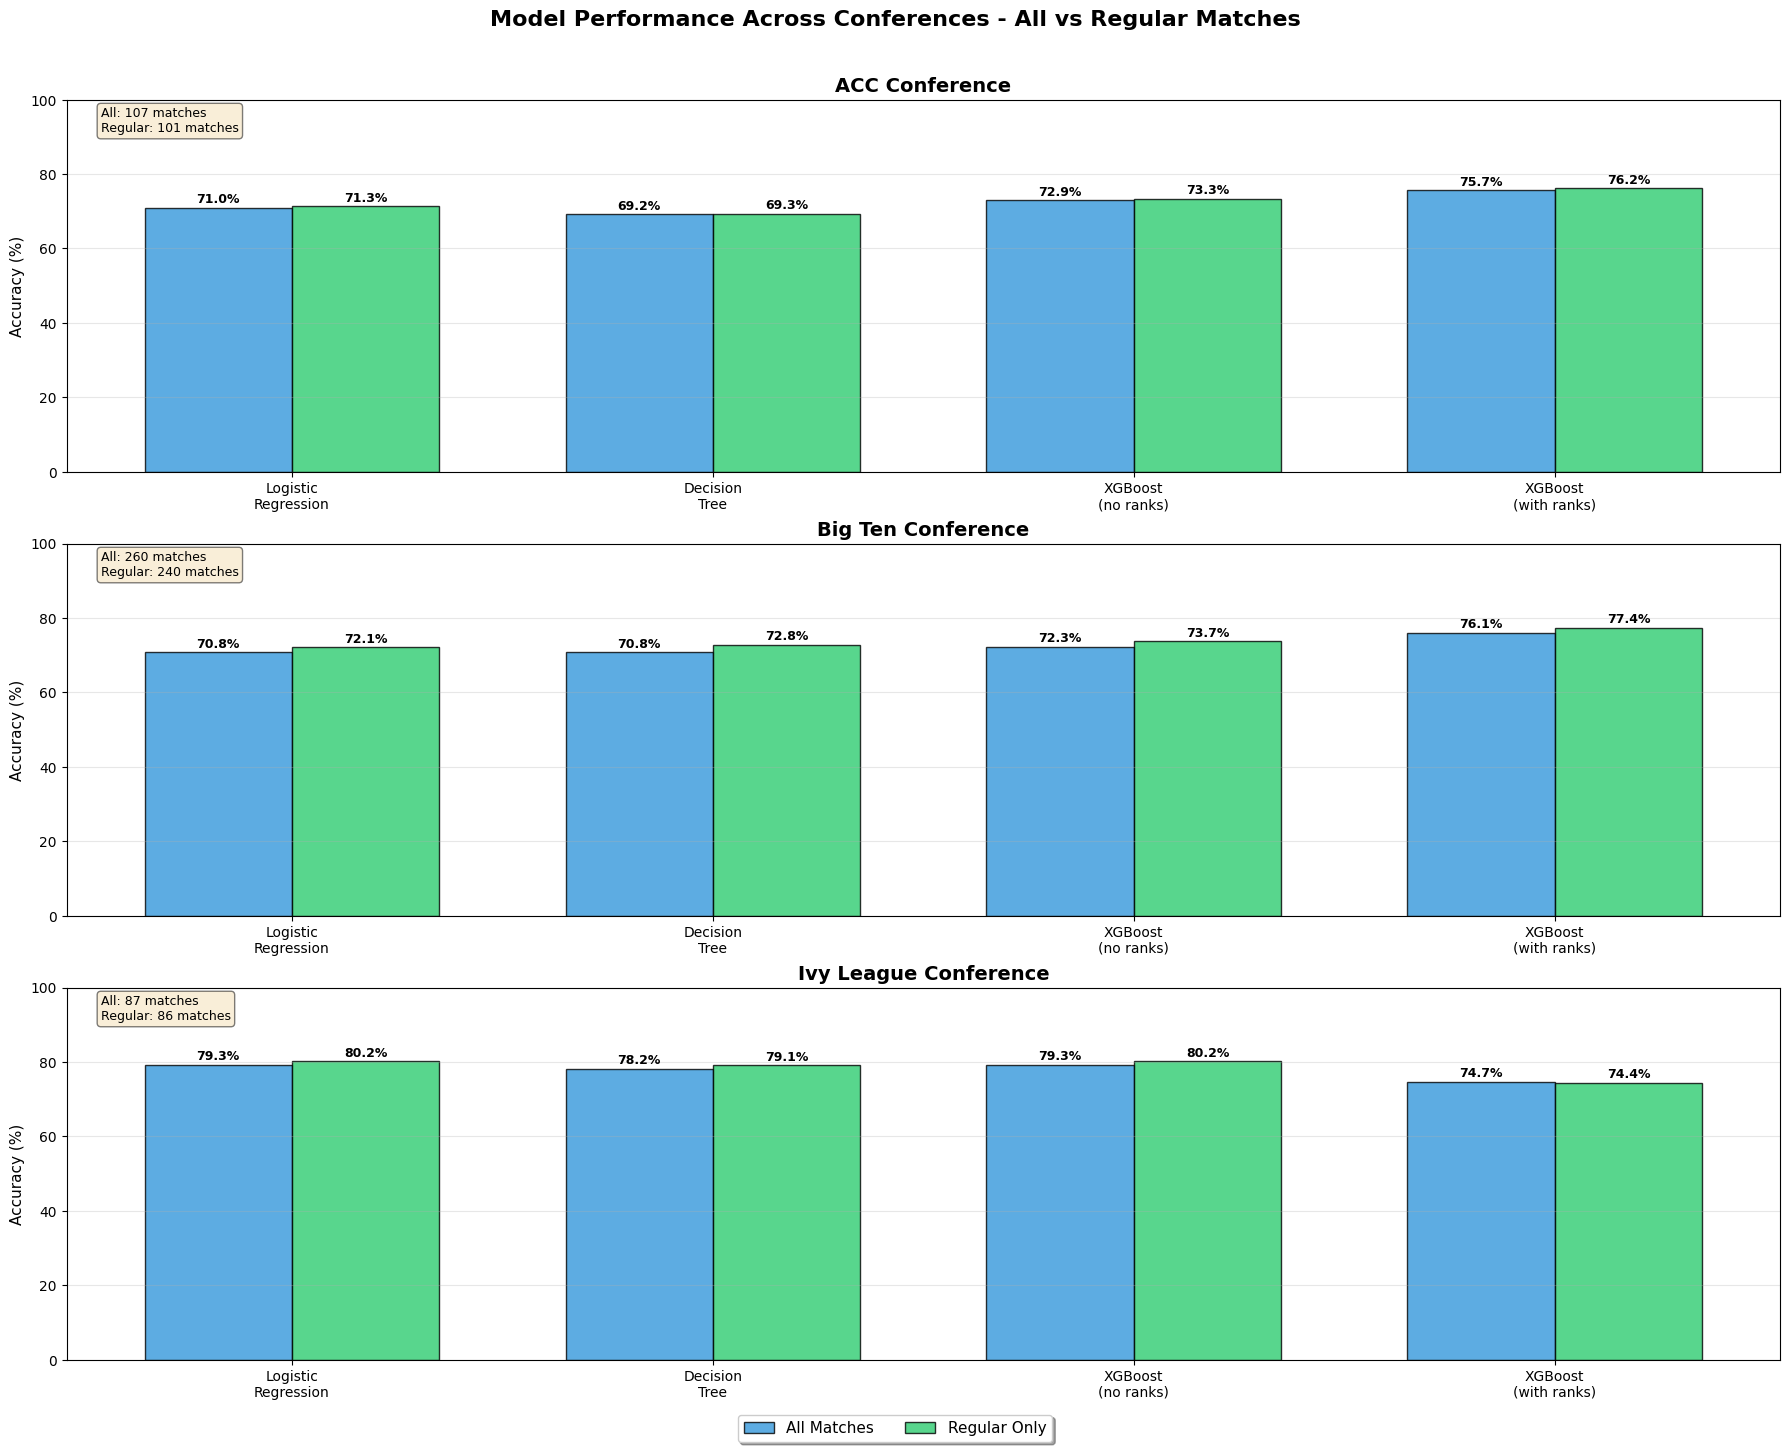


📊 OVERALL MODEL PERFORMANCE - ALL CONFERENCES COMBINED

Total matches across all conferences:
  All matches: 1816
  Regular matches: 1708
  Special matches: 108

🔴 OVERALL - ALL MATCHES (All Conferences Combined):


,Model,Correct,Accuracy
3,XGBoost (with ranks),344/454,75.8
2,XGBoost (no ranks),335/454,73.8
1,Logistic Regression,329/454,72.5
0,Decision Tree,326/454,71.8



🟢 OVERALL - REGULAR MATCHES ONLY (All Conferences Combined):


,Model,Correct,Accuracy
3,XGBoost (with ranks),327/427,76.6
2,XGBoost (no ranks),320/427,74.9
1,Logistic Regression,314/427,73.5
0,Decision Tree,313/427,73.3



🏆 OVERALL CHAMPION PREDICTION ACCURACY - ALL CONFERENCES

📊 Champion Prediction Accuracy by Conference:


,Conference,Total Champions,Correct,Accuracy
0,ACC,10,21,21/10 (210.0%)
1,Big Ten,10,30,30/10 (300.0%)
2,Ivy League,10,26,26/10 (260.0%)



🏆 Overall Champion Prediction Accuracy: 77/30 (256.7%)

📊 MODEL RANKING BY CONFERENCE


Model                    Decision Tree  Logistic Regression  \
Conference Match Type                                         
ACC        All Matches            69.2                 71.0   
           Regular Only           69.3                 71.3   
Big Ten    All Matches            70.8                 70.8   
           Regular Only           72.8                 72.1   
Ivy League All Matches            78.2                 79.3   
           Regular Only           79.1                 80.2   

Model                    XGBoost (no ranks)  XGBoost (with ranks)  
Conference Match Type                                              
ACC        All Matches                 72.9                  75.7  
           Regular Only                73.3                  76.2  
Big Ten    All Matches                 72.3                  76.1  
           Regular Only                73.7                  77.4  
Ivy League All Matches                 79.3                  74.7  
           Regular Only                80.2                  74.4

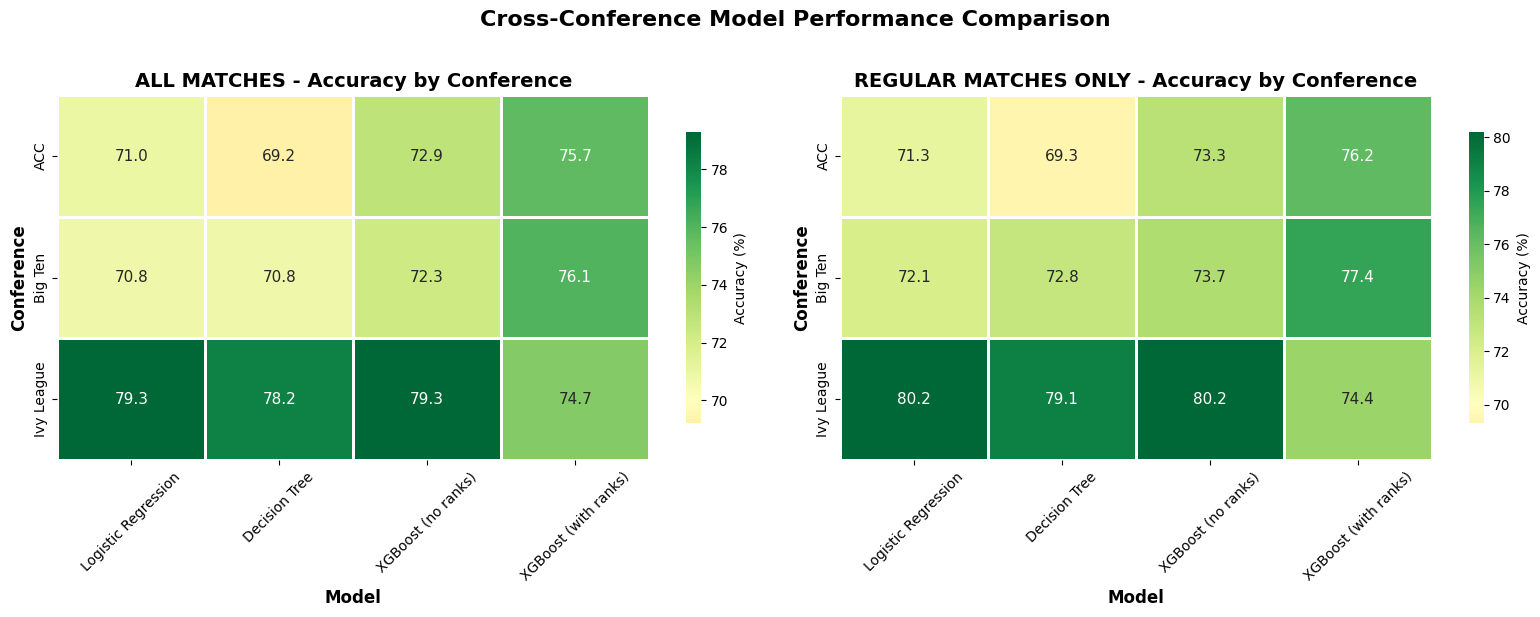

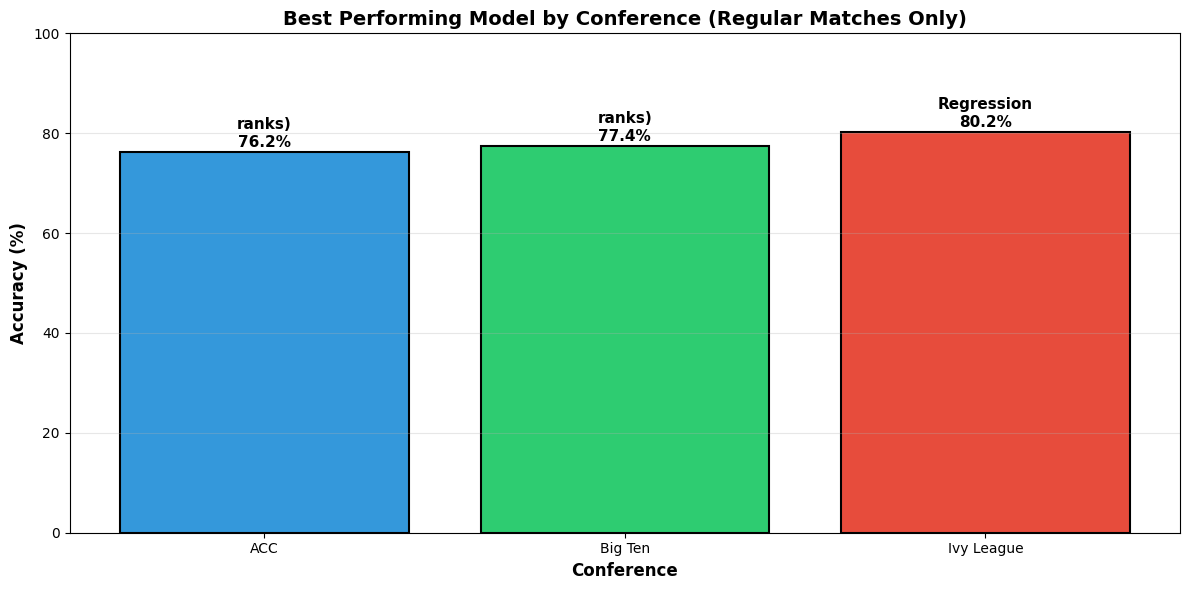

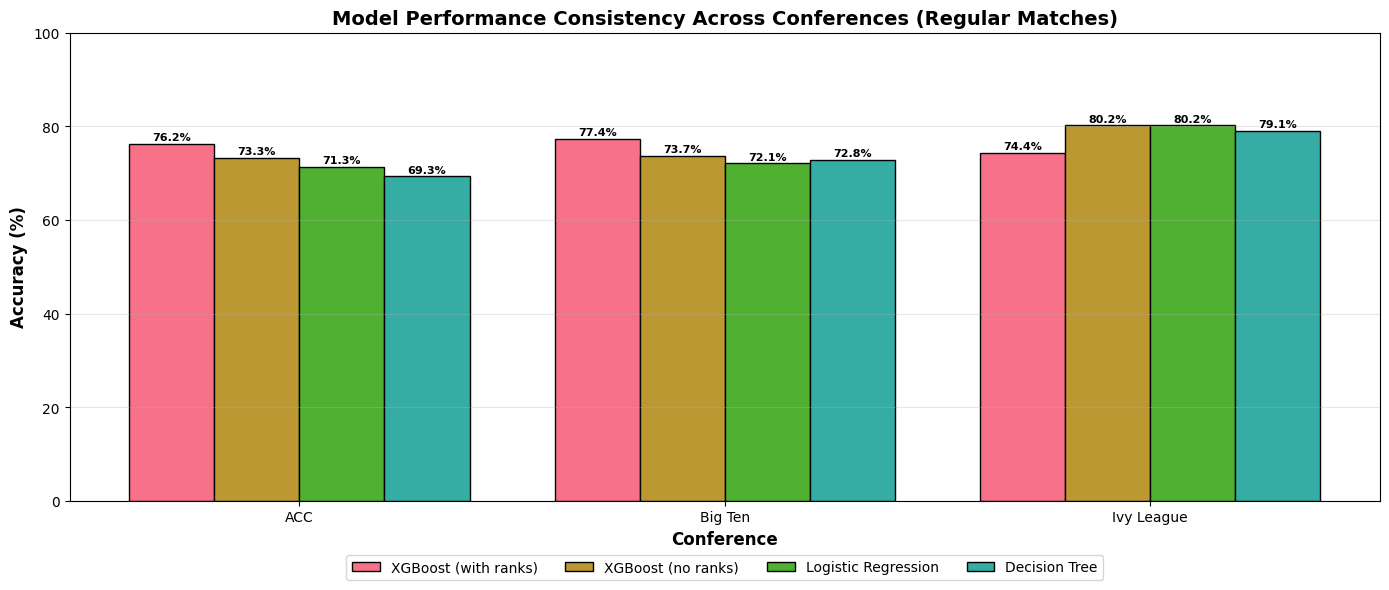


📊 OVERALL CROSS-CONFERENCE SUMMARY


,Model,Champion Accuracy,All Matches Accuracy,Regular Matches Accuracy
3,XGBoost (with ranks),19/30 (63.3%),75.8%,76.6%
2,XGBoost (no ranks),21/30 (70.0%),73.8%,74.9%
0,Logistic Regression,19/30 (63.3%),72.5%,73.5%
1,Decision Tree,18/30 (60.0%),71.8%,73.3%



✅ OVERALL CROSS-CONFERENCE ANALYSIS COMPLETE


In [29]:
# ============================================
# OVERALL CROSS-CONFERENCE ANALYSIS - FIXED
# ============================================
# Set style
plt.style.use('default')
sns.set_palette("husl")

print("\n" + "="*100)
print("📊 OVERALL CROSS-CONFERENCE MODEL PERFORMANCE ANALYSIS")
print("="*100)

# ============================================
# FUNCTION TO EXTRACT NUMBERS FROM STRINGS
# ============================================

def extract_correct_total(val):
    """Extract correct and total from strings like '198/260' or '81/107'"""
    if isinstance(val, str):
        # Handle formats like '198/260'
        if '/' in val:
            parts = val.split('/')
            return int(parts[0]), int(parts[1])
        # Handle formats like '81/107' or other variations
        match = re.search(r'(\d+)/(\d+)', val)
        if match:
            return int(match.group(1)), int(match.group(2))
    return None, None

# ============================================
# MANUALLY CREATE DATAFRAMES FROM YOUR DATA
# ============================================

# ACC Data
acc_all_matches = pd.DataFrame([
    {'Model': 'XGBoost (with ranks)', 'Correct': 81, 'Total': 107, 'Accuracy': 75.7},
    {'Model': 'XGBoost (no ranks)', 'Correct': 78, 'Total': 107, 'Accuracy': 72.9},
    {'Model': 'Logistic Regression', 'Correct': 76, 'Total': 107, 'Accuracy': 71.0},
    {'Model': 'Decision Tree', 'Correct': 74, 'Total': 107, 'Accuracy': 69.2},
])
acc_all_matches['Conference'] = 'ACC'

acc_regular_matches = pd.DataFrame([
    {'Model': 'XGBoost (with ranks)', 'Correct': 77, 'Total': 101, 'Accuracy': 76.2},
    {'Model': 'XGBoost (no ranks)', 'Correct': 74, 'Total': 101, 'Accuracy': 73.3},
    {'Model': 'Logistic Regression', 'Correct': 72, 'Total': 101, 'Accuracy': 71.3},
    {'Model': 'Decision Tree', 'Correct': 70, 'Total': 101, 'Accuracy': 69.3},
])
acc_regular_matches['Conference'] = 'ACC'

# Big Ten Data
bigten_all_matches = pd.DataFrame([
    {'Model': 'XGBoost (with ranks)', 'Correct': 198, 'Total': 260, 'Accuracy': 76.1},
    {'Model': 'XGBoost (no ranks)', 'Correct': 188, 'Total': 260, 'Accuracy': 72.3},
    {'Model': 'Logistic Regression', 'Correct': 184, 'Total': 260, 'Accuracy': 70.8},
    {'Model': 'Decision Tree', 'Correct': 184, 'Total': 260, 'Accuracy': 70.8},
])
bigten_all_matches['Conference'] = 'Big Ten'

bigten_regular_matches = pd.DataFrame([
    {'Model': 'XGBoost (with ranks)', 'Correct': 186, 'Total': 240, 'Accuracy': 77.4},
    {'Model': 'XGBoost (no ranks)', 'Correct': 177, 'Total': 240, 'Accuracy': 73.7},
    {'Model': 'Decision Tree', 'Correct': 175, 'Total': 240, 'Accuracy': 72.8},
    {'Model': 'Logistic Regression', 'Correct': 173, 'Total': 240, 'Accuracy': 72.1},
])
bigten_regular_matches['Conference'] = 'Big Ten'

# Ivy League Data
ivy_all_matches = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Correct': 69, 'Total': 87, 'Accuracy': 79.3},
    {'Model': 'XGBoost (no ranks)', 'Correct': 69, 'Total': 87, 'Accuracy': 79.3},
    {'Model': 'Decision Tree', 'Correct': 68, 'Total': 87, 'Accuracy': 78.2},
    {'Model': 'XGBoost (with ranks)', 'Correct': 65, 'Total': 87, 'Accuracy': 74.7},
])
ivy_all_matches['Conference'] = 'Ivy League'

ivy_regular_matches = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Correct': 69, 'Total': 86, 'Accuracy': 80.2},
    {'Model': 'XGBoost (no ranks)', 'Correct': 69, 'Total': 86, 'Accuracy': 80.2},
    {'Model': 'Decision Tree', 'Correct': 68, 'Total': 86, 'Accuracy': 79.1},
    {'Model': 'XGBoost (with ranks)', 'Correct': 64, 'Total': 86, 'Accuracy': 74.4},
])
ivy_regular_matches['Conference'] = 'Ivy League'

# Combine all data
all_matches_combined = pd.concat([acc_all_matches, bigten_all_matches, ivy_all_matches], ignore_index=True)
all_regular_matches_combined = pd.concat([acc_regular_matches, bigten_regular_matches, ivy_regular_matches], ignore_index=True)

# Champion accuracy data
acc_champion = pd.DataFrame([
    {'Model': 'LOGREG', 'Correct Champions': '4/10', 'Accuracy': '40.0%', 'Conference': 'ACC'},
    {'Model': 'DT', 'Correct Champions': '5/10', 'Accuracy': '50.0%', 'Conference': 'ACC'},
    {'Model': 'XGB1', 'Correct Champions': '6/10', 'Accuracy': '60.0%', 'Conference': 'ACC'},
    {'Model': 'XGB2', 'Correct Champions': '6/10', 'Accuracy': '60.0%', 'Conference': 'ACC'},
])

bigten_champion = pd.DataFrame([
    {'Model': 'LOGREG', 'Correct Champions': '8/10', 'Accuracy': '80.0%', 'Conference': 'Big Ten'},
    {'Model': 'DT', 'Correct Champions': '7/10', 'Accuracy': '70.0%', 'Conference': 'Big Ten'},
    {'Model': 'XGB1', 'Correct Champions': '8/10', 'Accuracy': '80.0%', 'Conference': 'Big Ten'},
    {'Model': 'XGB2', 'Correct Champions': '7/10', 'Accuracy': '70.0%', 'Conference': 'Big Ten'},
])

ivy_champion = pd.DataFrame([
    {'Model': 'LOGREG', 'Correct Champions': '7/10', 'Accuracy': '70.0%', 'Conference': 'Ivy League'},
    {'Model': 'DT', 'Correct Champions': '6/10', 'Accuracy': '60.0%', 'Conference': 'Ivy League'},
    {'Model': 'XGB1', 'Correct Champions': '7/10', 'Accuracy': '70.0%', 'Conference': 'Ivy League'},
    {'Model': 'XGB2', 'Correct Champions': '6/10', 'Accuracy': '60.0%', 'Conference': 'Ivy League'},
])

all_champion_accuracy = pd.concat([acc_champion, bigten_champion, ivy_champion], ignore_index=True)

# Map model names
model_name_map = {
    'LOGREG': 'Logistic Regression',
    'DT': 'Decision Tree',
    'XGB1': 'XGBoost (no ranks)',
    'XGB2': 'XGBoost (with ranks)'
}
all_champion_accuracy['Model'] = all_champion_accuracy['Model'].map(model_name_map)

# ============================================
# FIGURE 1: 3x1 Subplot - All Conferences Side by Side
# ============================================

# ============================================
# FIGURE 1: 3x1 Subplot - All Conferences Side by Side (FIXED X-AXIS)
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(18, 15))
fig.suptitle('Model Performance Across Conferences - All vs Regular Matches', fontsize=16, fontweight='bold', y=0.98)

conferences = ['ACC', 'Big Ten', 'Ivy League']
colors = {'All Matches': '#3498db', 'Regular Only': '#2ecc71'}

# Define proper labels for x-axis
model_labels = ['Logistic\nRegression', 'Decision\nTree', 'XGBoost\n(no ranks)', 'XGBoost\n(with ranks)']

for idx, conf in enumerate(conferences):
    ax = axes[idx]

    # Get data for this conference
    conf_all = all_matches_combined[all_matches_combined['Conference'] == conf].copy()
    conf_reg = all_regular_matches_combined[all_regular_matches_combined['Conference'] == conf].copy()

    # Sort by model for consistency
    model_order = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']

    x = np.arange(len(model_order))
    width = 0.35

    # Extract accuracy values
    all_acc = []
    reg_acc = []

    for model in model_order:
        # All matches accuracy
        all_val = conf_all[conf_all['Model'] == model]['Accuracy'].values[0]
        all_acc.append(float(all_val))

        # Regular matches accuracy
        reg_val = conf_reg[conf_reg['Model'] == model]['Accuracy'].values[0]
        reg_acc.append(float(reg_val))

    # Create bars
    bars1 = ax.bar(x - width/2, all_acc, width,
                   label='All Matches' if idx == 0 else "",
                   color='#3498db', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x + width/2, reg_acc, width,
                   label='Regular Only' if idx == 0 else "",
                   color='#2ecc71', edgecolor='black', alpha=0.8)

    # Add value labels
    for i, (all_val, reg_val) in enumerate(zip(all_acc, reg_acc)):
        ax.text(i - width/2, all_val + 0.5, f'{all_val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
        ax.text(i + width/2, reg_val + 0.5, f'{reg_val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

    # Customize
    ax.set_title(f'{conf} Conference', fontweight='bold', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=10)  # Using proper multi-line labels
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

    # Add total matches info
    total_all = conf_all['Total'].iloc[0]
    total_reg = conf_reg['Total'].iloc[0]
    ax.text(0.02, 0.98, f'All: {total_all} matches\nRegular: {total_reg} matches',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add legend in a better location - bottom center
fig.legend(['All Matches', 'Regular Only'],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=2,
           fontsize=11,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.08)  # Adjust bottom to make room for legend
plt.show()

# ============================================
# OVERALL MODEL PERFORMANCE ACROSS ALL CONFERENCES
# ============================================

print("\n" + "="*100)
print("📊 OVERALL MODEL PERFORMANCE - ALL CONFERENCES COMBINED")
print("="*100)

# Calculate overall totals
total_all_matches = all_matches_combined['Total'].sum()
total_regular_matches = all_regular_matches_combined['Total'].sum()

print(f"\nTotal matches across all conferences:")
print(f"  All matches: {total_all_matches}")
print(f"  Regular matches: {total_regular_matches}")
print(f"  Special matches: {total_all_matches - total_regular_matches}")

# Overall accuracy by model (all matches)
overall_all = all_matches_combined.groupby('Model').agg({
    'Correct': 'sum',
    'Total': 'sum'
}).reset_index()
overall_all['Accuracy'] = (overall_all['Correct'] / overall_all['Total'] * 100).round(1)
overall_all = overall_all.sort_values('Accuracy', ascending=False)
overall_all['Correct'] = overall_all['Correct'].astype(str) + '/' + overall_all['Total'].astype(str)

print("\n🔴 OVERALL - ALL MATCHES (All Conferences Combined):")
display(overall_all[['Model', 'Correct', 'Accuracy']])

# Overall accuracy by model (regular matches only)
overall_reg = all_regular_matches_combined.groupby('Model').agg({
    'Correct': 'sum',
    'Total': 'sum'
}).reset_index()
overall_reg['Accuracy'] = (overall_reg['Correct'] / overall_reg['Total'] * 100).round(1)
overall_reg = overall_reg.sort_values('Accuracy', ascending=False)
overall_reg['Correct'] = overall_reg['Correct'].astype(str) + '/' + overall_reg['Total'].astype(str)

print("\n🟢 OVERALL - REGULAR MATCHES ONLY (All Conferences Combined):")
display(overall_reg[['Model', 'Correct', 'Accuracy']])

# ============================================
# OVERALL CHAMPION PREDICTION ACCURACY
# ============================================

print("\n" + "="*100)
print("🏆 OVERALL CHAMPION PREDICTION ACCURACY - ALL CONFERENCES")
print("="*100)

# Calculate champion accuracy by conference
champion_by_conf = []
for conf in conferences:
    conf_data = all_champion_accuracy[all_champion_accuracy['Conference'] == conf]
    total = len(conf_data)
    correct = 0
    for _, row in conf_data.iterrows():
        correct_val = int(row['Correct Champions'].split('/')[0])
        correct += correct_val
    champion_by_conf.append({
        'Conference': conf,
        'Total Champions': 10,
        'Correct': correct,
        'Accuracy': f"{correct}/10 ({correct/10*100:.1f}%)"
    })

champion_by_conf_df = pd.DataFrame(champion_by_conf)
print("\n📊 Champion Prediction Accuracy by Conference:")
display(champion_by_conf_df)

# Overall champion accuracy
total_champions = 30  # 3 conferences × 10 weights
correct_champions = champion_by_conf_df['Correct'].sum()
print(f"\n🏆 Overall Champion Prediction Accuracy: {correct_champions}/{total_champions} ({correct_champions/total_champions*100:.1f}%)")

# ============================================
# MODEL RANKING ACROSS CONFERENCES
# ============================================

print("\n" + "="*100)
print("📊 MODEL RANKING BY CONFERENCE")
print("="*100)

# Create ranking dataframe
ranking_data = []
for conf in conferences:
    conf_all = all_matches_combined[all_matches_combined['Conference'] == conf]
    conf_reg = all_regular_matches_combined[all_regular_matches_combined['Conference'] == conf]

    for _, row in conf_all.iterrows():
        ranking_data.append({
            'Conference': conf,
            'Model': row['Model'],
            'Match Type': 'All Matches',
            'Accuracy': row['Accuracy']
        })

    for _, row in conf_reg.iterrows():
        ranking_data.append({
            'Conference': conf,
            'Model': row['Model'],
            'Match Type': 'Regular Only',
            'Accuracy': row['Accuracy']
        })

ranking_df = pd.DataFrame(ranking_data)
ranking_pivot = ranking_df.pivot_table(
    index=['Conference', 'Match Type'],
    columns='Model',
    values='Accuracy'
).round(1)
display(ranking_pivot)

# ============================================
# FIGURE 2: Heatmap of Model Performance Across Conferences
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for heatmaps
heatmap_all = ranking_df[ranking_df['Match Type'] == 'All Matches'].pivot(
    index='Conference', columns='Model', values='Accuracy'
)
heatmap_reg = ranking_df[ranking_df['Match Type'] == 'Regular Only'].pivot(
    index='Conference', columns='Model', values='Accuracy'
)

# Reorder models
model_order = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']
heatmap_all = heatmap_all[model_order]
heatmap_reg = heatmap_reg[model_order]

# All matches heatmap
sns.heatmap(heatmap_all, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
            linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            annot_kws={'size': 11}, ax=axes[0])
axes[0].set_title('ALL MATCHES - Accuracy by Conference', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Conference', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Regular matches heatmap
sns.heatmap(heatmap_reg, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
            linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            annot_kws={'size': 11}, ax=axes[1])
axes[1].set_title('REGULAR MATCHES ONLY - Accuracy by Conference', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Conference', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Cross-Conference Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# FIGURE 3: Best Model by Conference
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

best_models = []
for conf in conferences:
    conf_data = ranking_df[(ranking_df['Conference'] == conf) & (ranking_df['Match Type'] == 'Regular Only')]
    best = conf_data.loc[conf_data['Accuracy'].idxmax()]
    best_models.append({
        'Conference': conf,
        'Best Model': best['Model'],
        'Accuracy': best['Accuracy']
    })

best_df = pd.DataFrame(best_models)
x = np.arange(len(best_df))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = ax.bar(x, best_df['Accuracy'], color=colors[:len(best_df)], edgecolor='black', linewidth=1.5)

# Add labels
for i, (bar, row) in enumerate(zip(bars, best_df.iterrows())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f"{row[1]['Best Model'].split()[-1]}\n{row[1]['Accuracy']:.1f}%",
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Conference', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Best Performing Model by Conference (Regular Matches Only)', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(best_df['Conference'])
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# FIGURE 4: Model Consistency Across Conferences
# ============================================

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate model rankings by conference
model_rankings = []
for model in model_order:
    model_data = ranking_df[(ranking_df['Model'] == model) & (ranking_df['Match Type'] == 'Regular Only')]
    acc_dict = {}
    for conf in conferences:
        acc = model_data[model_data['Conference'] == conf]['Accuracy'].values[0]
        acc_dict[conf] = acc
    model_rankings.append({
        'Model': model,
        'ACC': acc_dict['ACC'],
        'Big Ten': acc_dict['Big Ten'],
        'Ivy League': acc_dict['Ivy League'],
        'Avg': np.mean([acc_dict['ACC'], acc_dict['Big Ten'], acc_dict['Ivy League']]),
        'Std': np.std([acc_dict['ACC'], acc_dict['Big Ten'], acc_dict['Ivy League']])
    })

model_rank_df = pd.DataFrame(model_rankings)
model_rank_df = model_rank_df.sort_values('Avg', ascending=False)

# Create grouped bar chart
x = np.arange(len(conferences))
width = 0.2
multiplier = 0

for i, row in model_rank_df.iterrows():
    offset = width * multiplier
    bars = ax.bar(x + offset, [row['ACC'], row['Big Ten'], row['Ivy League']], width,
                  label=row['Model'], edgecolor='black', linewidth=1)

    # Add value labels
    for j, (bar, val) in enumerate(zip(bars, [row['ACC'], row['Big Ten'], row['Ivy League']])):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    multiplier += 1

ax.set_xlabel('Conference', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Consistency Across Conferences (Regular Matches)', fontweight='bold', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(conferences)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# SUMMARY TABLE
# ============================================

print("\n" + "="*100)
print("📊 OVERALL CROSS-CONFERENCE SUMMARY")
print("="*100)

summary_data = []
for model in model_order:
    # Champion accuracy
    model_champ = all_champion_accuracy[all_champion_accuracy['Model'] == model]
    total_correct = 0
    total_possible = 0
    for _, row in model_champ.iterrows():
        correct, total = row['Correct Champions'].split('/')
        total_correct += int(correct)
        total_possible += int(total)
    champ_acc = total_correct / total_possible * 100

    # Match accuracy
    model_all = overall_all[overall_all['Model'] == model]
    model_reg = overall_reg[overall_reg['Model'] == model]

    summary_data.append({
        'Model': model,
        'Champion Accuracy': f"{total_correct}/{total_possible} ({champ_acc:.1f}%)",
        'All Matches Accuracy': f"{model_all['Accuracy'].values[0]:.1f}%",
        'Regular Matches Accuracy': f"{model_reg['Accuracy'].values[0]:.1f}%",
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Regular Matches Accuracy', ascending=False)
display(summary_df)

# ============================================
# SAVE OVERALL RESULTS
# ============================================

# print("\n💾 SAVING OVERALL CROSS-CONFERENCE DATAFRAMES...")

# overall_all.to_csv('overall_all_conferences_all_matches.csv', index=False)
# print("   ✅ Saved: overall_all_conferences_all_matches.csv")

# overall_reg.to_csv('overall_all_conferences_regular_matches.csv', index=False)
# print("   ✅ Saved: overall_all_conferences_regular_matches.csv")

# summary_df.to_csv('overall_model_summary.csv', index=False)
# print("   ✅ Saved: overall_model_summary.csv")

# ranking_pivot.to_csv('overall_model_ranking_by_conference.csv')
# print("   ✅ Saved: overall_model_ranking_by_conference.csv")

print("\n" + "="*100)
print("✅ OVERALL CROSS-CONFERENCE ANALYSIS COMPLETE")
print("="*100)